In [6]:
#import&read
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/toiizumitarou/day2/sample_day2.csv")
df.head()

,patient_id,age,value,date,flag
0,patient_id,age,value,date,flag
1,1,34,5.4,2024-01-01,0
2,2,58,7.1,2024-01-02,1
3,3,45,6.1,2024-01-03,0
4,4,52,7.8,2024-01-04,1


In [12]:
# 数値カラムを強制的に数値に変換（できないものはNaN）
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["flag"] = pd.to_numeric(df["flag"], errors="coerce")

# patient_id は整数扱いにできる
df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

# 日付の型変換
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 欠損値があれば削除（AI用データの前提条件）
df = df.dropna()

df.dtypes

/var/folders/by/yd89_rh944vfysllq_zmnfyw0000gn/T/ipykernel_31196/3758884599.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


patient_id           float64
age                  float64
value                float64
date          datetime64[ns]
flag                 float64
dtype: object

In [14]:
#相関の確認
df.corr()

,patient_id,age,value,date,flag
patient_id,1.000000,0.002256,0.020359,1.000000,0.007621
age,0.002256,1.000000,0.963899,0.002256,0.870005
value,0.020359,0.963899,1.000000,0.020359,0.885365
date,1.000000,0.002256,0.020359,1.000000,0.007621
flag,0.007621,0.870005,0.885365,0.007621,1.000000


In [18]:
#基本統計量
df.describe()

,patient_id,age,value,date,flag
count,100.000000,100.000000,100.000000,100,100.000000
mean,50.500000,45.560000,6.522000,2024-02-19 12:00:00,0.500000
min,1.000000,26.000000,4.500000,2024-01-01 00:00:00,0.000000
25%,25.750000,36.000000,5.475000,2024-01-25 18:00:00,0.000000
50%,50.500000,45.000000,6.450000,2024-02-19 12:00:00,0.500000
75%,75.250000,55.250000,7.600000,2024-03-15 06:00:00,1.000000
max,100.000000,64.000000,8.400000,2024-04-09 00:00:00,1.000000
std,29.011492,11.113119,1.178304,NaN,0.502519


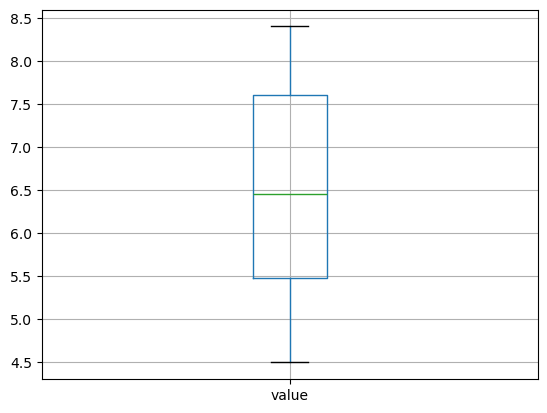

In [20]:
#valueの外れ値チェック（箱ひげ図）
df.boxplot(column="value")
plt.show()

In [22]:
#flagごとのvalueの平均値
df.groupby("flag")["value"].mean()

flag
0.0    5.484
1.0    7.560
Name: value, dtype: float64

In [30]:
#年齢層ごとの検査値の違い
df.groupby("age")["value"].mean()

age
26.0    4.500000
27.0    4.600000
28.0    4.766667
29.0    4.800000
30.0    4.833333
31.0    5.050000
32.0    5.100000
33.0    5.533333
34.0    5.333333
35.0    5.150000
36.0    5.666667
37.0    5.725000
38.0    5.266667
39.0    5.600000
40.0    6.200000
41.0    6.000000
42.0    6.133333
43.0    6.250000
44.0    6.850000
45.0    6.166667
46.0    6.500000
47.0    6.950000
48.0    6.450000
49.0    6.933333
50.0    7.350000
51.0    7.700000
52.0    7.466667
53.0    7.400000
54.0    7.566667
55.0    7.533333
56.0    7.200000
57.0    7.633333
58.0    7.666667
59.0    7.500000
60.0    8.066667
61.0    8.266667
62.0    8.166667
63.0    8.300000
64.0    8.250000
Name: value, dtype: float64

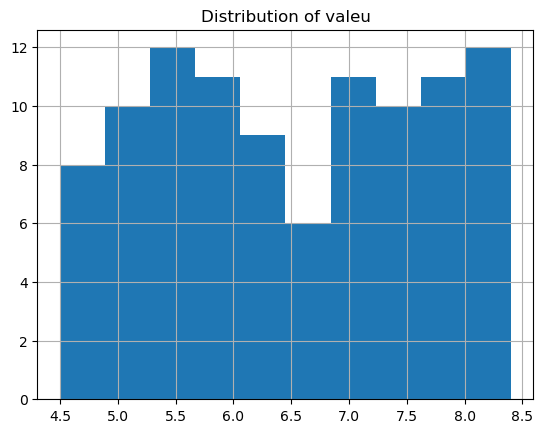

In [32]:
# 可視化
#ヒストグラム（分布可視化）
df["value"].hist()
plt.title("Distribution of valeu")
plt.show()

In [44]:
df.columns

Index(['patient_id', 'age', 'value', 'date', 'flag'], dtype='object')

In [46]:
#age_groupを再作成する
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, 120],
    labels=["young", "middle", "senior"]
)

In [48]:
df.columns
df["age_group"].head()

1     young
2    middle
3    middle
4    middle
5    middle
Name: age_group, dtype: category
Categories (3, object): ['young' < 'middle' < 'senior']

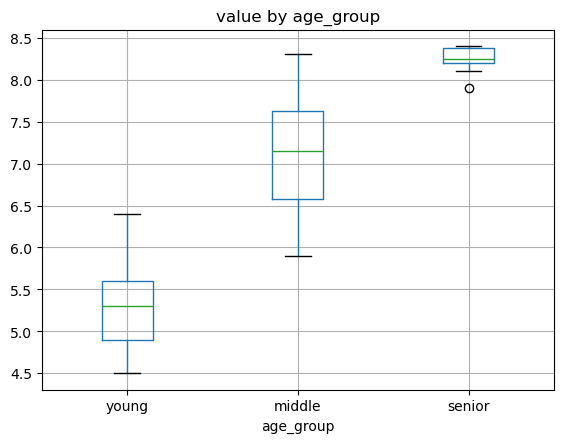

In [50]:
#age_group*value箱ひげ図
df.boxplot(column="value", by="age_group")
plt.title("value by age_group")
plt.suptitle("")
plt.show()

In [54]:
df.groupby("flag")["value"].mean()

flag
0.0    5.484
1.0    7.560
Name: value, dtype: float64

In [62]:
df["high_risk"] = (df["value"] > 7.5).astype(int)

In [68]:
df["high_risk"].head()

1    0
2    0
3    0
4    1
5    0
Name: high_risk, dtype: int64

In [70]:
df.groupby("flag")["value"].mean()

flag
0.0    5.484
1.0    7.560
Name: value, dtype: float64

In [74]:
df.groupby("flag")["high_risk"].mean()

flag
0.0    0.00
1.0    0.52
Name: high_risk, dtype: float64